In [1]:
!pip install pandas numpy matplotlib seaborn wordcloud nltk scikit-learn imbalanced-learn transformers torch -q
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
print("Hazır!")

Hazır!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

base = "https://raw.githubusercontent.com/Kayal-Sampath/detecting-signs-of-depression-from-social-media-postings/main/"

train = pd.read_csv(base + "train.tsv", sep='\t')
test  = pd.read_csv(base + "test.tsv",  sep='\t')
dev   = pd.read_csv(base + "dev.tsv",   sep='\t')

df2 = pd.concat([train, test, dev], ignore_index=True)

print(f"Train: {len(train)}, Test: {len(test)}, Dev: {len(dev)}")
print(f"Toplam: {df2.shape[0]} satır, {df2.shape[1]} sütun")
print(f"Sütunlar: {list(df2.columns)}")
print(f"\nEksik değer:\n{df2.isnull().sum()}")
print(f"\nİlk 3 satır:\n{df2.head(3)}")

Train: 8891, Test: 3245, Dev: 4496
Toplam: 16632 satır, 7 sütun
Sütunlar: ['PID', 'Text_data', 'Label', 'Pid', 'text data', 'Class labels', 'Text data']

Eksik değer:
PID              3245
Text_data        7741
Label            3245
Pid             13387
text data       13387
Class labels    13387
Text data       12136
dtype: int64

İlk 3 satır:
           PID                                          Text_data     Label  \
0  train_pid_1  Waiting for my mind to have a breakdown once t...  moderate   
1  train_pid_2  My new years resolution : I'm gonna get my ass...  moderate   
2  train_pid_3  New year : Somone else Feeling like 2020 will ...  moderate   

   Pid text data Class labels Text data  
0  NaN       NaN          NaN       NaN  
1  NaN       NaN          NaN       NaN  
2  NaN       NaN          NaN       NaN  


In [4]:
df2 = train[['Text_data', 'Label']].copy()
df2.columns = ['text', 'label']
df2 = df2.dropna()
df2 = df2.reset_index(drop=True)

print(f"Satır: {len(df2)}")
print(f"\nSınıf dağılımı:\n{df2['label'].value_counts()}")
print(f"\nYüzde:\n{df2['label'].value_counts(normalize=True).mul(100).round(1)}")
print(f"\nİlk 3 satır:\n{df2.head(3)}")

Satır: 8891

Sınıf dağılımı:
label
moderate          6004
not depression    1985
severe             902
Name: count, dtype: int64

Yüzde:
label
moderate          67.5
not depression    22.3
severe            10.1
Name: proportion, dtype: float64

İlk 3 satır:
                                                text     label
0  Waiting for my mind to have a breakdown once t...  moderate
1  My new years resolution : I'm gonna get my ass...  moderate
2  New year : Somone else Feeling like 2020 will ...  moderate


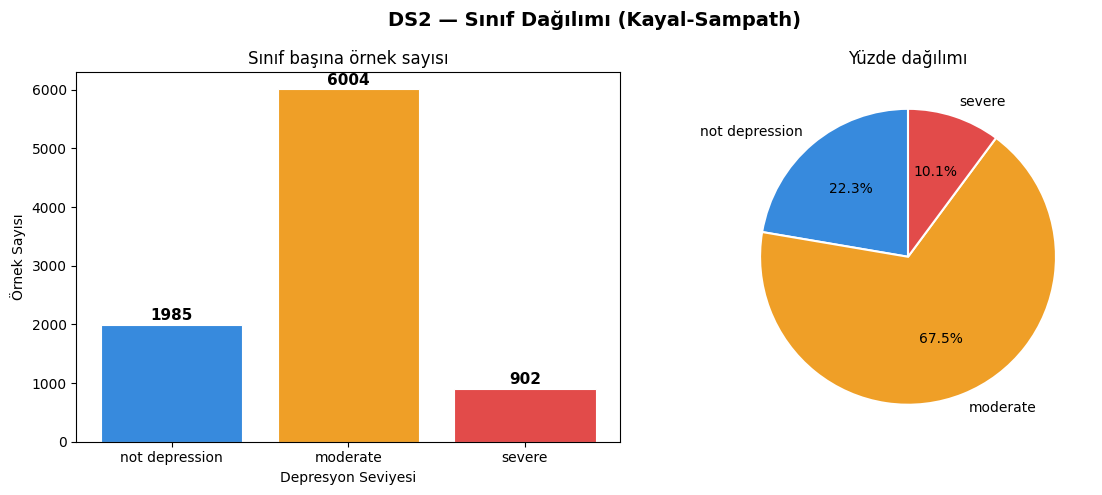

In [5]:
import matplotlib.pyplot as plt

label_order  = ['not depression', 'moderate', 'severe']
label_colors = ['#378ADD', '#EF9F27', '#E24B4A']
counts = df2['label'].value_counts().reindex(label_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('DS2 — Sınıf Dağılımı (Kayal-Sampath)', fontsize=14, fontweight='bold')

bars = axes[0].bar(label_order, counts.values, color=label_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Sınıf başına örnek sayısı')
axes[0].set_xlabel('Depresyon Seviyesi')
axes[0].set_ylabel('Örnek Sayısı')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=label_order, colors=label_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Yüzde dağılımı')

plt.tight_layout()
plt.savefig('ds2_sinif_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

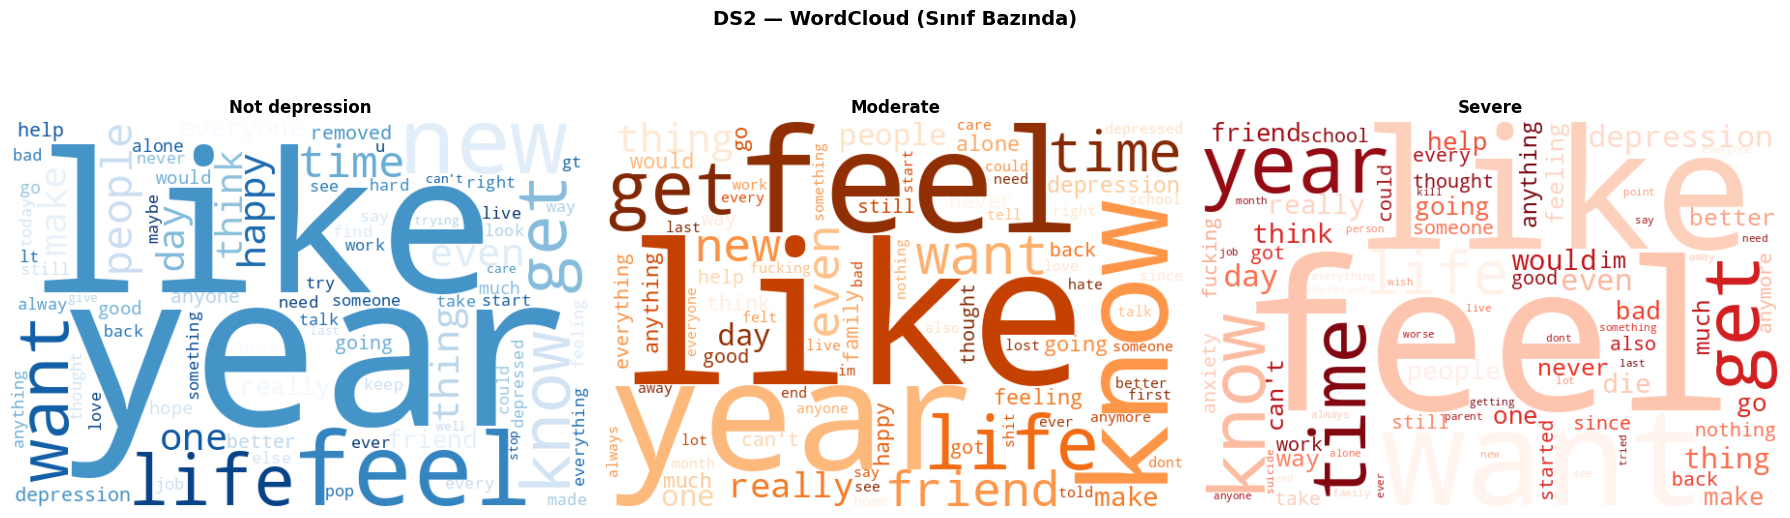

In [6]:
import re
from nltk.corpus import stopwords
from wordcloud import WordCloud

stop_words = set(stopwords.words('english'))
label_order  = ['not depression', 'moderate', 'severe']
wc_colors = ['Blues', 'Oranges', 'Reds']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('DS2 — WordCloud (Sınıf Bazında)', fontsize=14, fontweight='bold')

for ax, lbl, cmap in zip(axes, label_order, wc_colors):
    text = ' '.join(df2[df2['label'] == lbl]['text'].astype(str).tolist())
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        stopwords=stop_words,
        colormap=cmap,
        max_words=80,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(lbl.capitalize(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('ds2_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import re

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df2['text_clean'] = df2['text'].apply(preprocess)

le2 = LabelEncoder()
df2['label_enc'] = le2.fit_transform(df2['label'])

print("Etiket mapping:")
for i, cls in enumerate(le2.classes_):
    print(f"  {i} → {cls}")

X2 = df2['text_clean']
y2 = df2['label_enc']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

tfidf2 = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X2_train_tfidf = tfidf2.fit_transform(X2_train)
X2_test_tfidf  = tfidf2.transform(X2_test)

smote2 = SMOTE(random_state=42)
X2_train_bal, y2_train_bal = smote2.fit_resample(X2_train_tfidf, y2_train)

print(f"\nTrain: {X2_train_tfidf.shape} → SMOTE sonrası: {X2_train_bal.shape}")
print(f"Test : {X2_test_tfidf.shape}")
print(f"\nSMOTE sonrası dağılım:\n{pd.Series(y2_train_bal).value_counts().sort_index()}")

Etiket mapping:
  0 → moderate
  1 → not depression
  2 → severe

Train: (7112, 10000) → SMOTE sonrası: (14409, 10000)
Test : (1779, 10000)

SMOTE sonrası dağılım:
label_enc
0    4803
1    4803
2    4803
Name: count, dtype: int64


DS2 — SVM Classification Report
                precision    recall  f1-score   support

      moderate       0.92      0.94      0.93      1201
not depression       0.83      0.78      0.80       397
        severe       0.81      0.79      0.80       181

      accuracy                           0.89      1779
     macro avg       0.85      0.84      0.84      1779
  weighted avg       0.89      0.89      0.89      1779



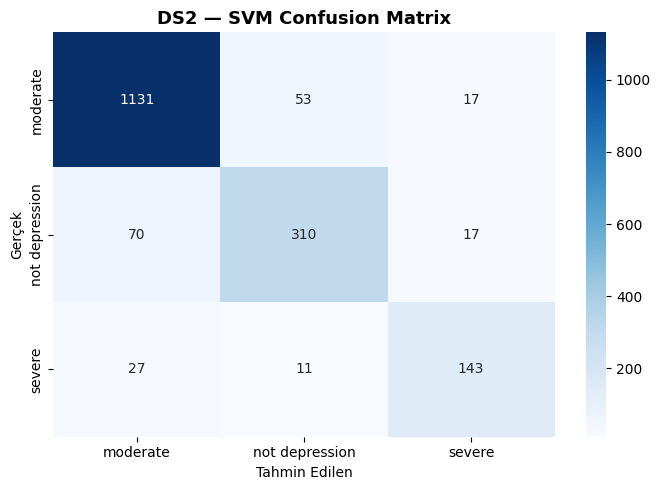

In [8]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

label_names2 = le2.classes_

svm2 = LinearSVC(random_state=42, max_iter=2000)
svm2.fit(X2_train_bal, y2_train_bal)
y2_pred_svm = svm2.predict(X2_test_tfidf)

print("=" * 50)
print("DS2 — SVM Classification Report")
print("=" * 50)
print(classification_report(y2_test, y2_pred_svm, target_names=label_names2))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y2_test, y2_pred_svm), annot=True, fmt='d',
            cmap='Blues', xticklabels=label_names2, yticklabels=label_names2, ax=ax)
ax.set_title('DS2 — SVM Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin Edilen')
ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig('ds2_svm_cm.png', dpi=150, bbox_inches='tight')
plt.show()

DS2 — Random Forest Classification Report
                precision    recall  f1-score   support

      moderate       0.89      0.96      0.92      1201
not depression       0.87      0.74      0.80       397
        severe       0.89      0.68      0.77       181

      accuracy                           0.88      1779
     macro avg       0.88      0.79      0.83      1779
  weighted avg       0.88      0.88      0.88      1779



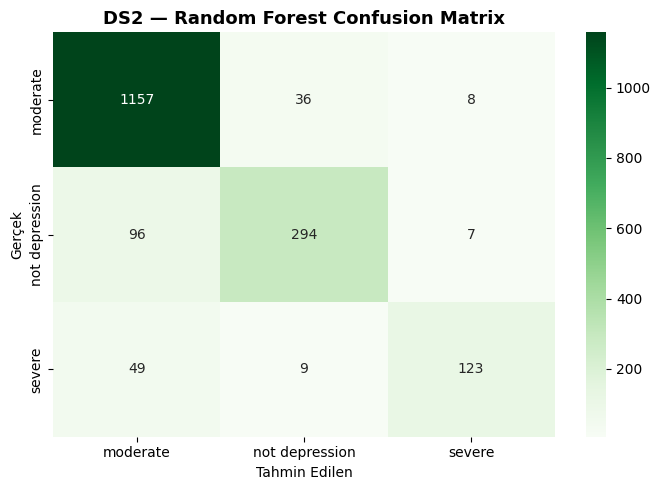

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf2.fit(X2_train_bal, y2_train_bal)
y2_pred_rf = rf2.predict(X2_test_tfidf)

print("=" * 50)
print("DS2 — Random Forest Classification Report")
print("=" * 50)
print(classification_report(y2_test, y2_pred_rf, target_names=label_names2))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y2_test, y2_pred_rf), annot=True, fmt='d',
            cmap='Greens', xticklabels=label_names2, yticklabels=label_names2, ax=ax)
ax.set_title('DS2 — Random Forest Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin Edilen')
ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig('ds2_rf_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

MAX_WORDS = 10000
MAX_LEN   = 150

tokenizer2 = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer2.fit_on_texts(X2_train)

X2_train_pad = pad_sequences(tokenizer2.texts_to_sequences(X2_train), maxlen=MAX_LEN, padding='post')
X2_test_pad  = pad_sequences(tokenizer2.texts_to_sequences(X2_test),  maxlen=MAX_LEN, padding='post')

class_weights2 = compute_class_weight('balanced', classes=np.unique(y2_train), y=y2_train)
class_weight_dict2 = dict(enumerate(class_weights2))
print("Sınıf ağırlıkları:", class_weight_dict2)

model_bilstm2 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_bilstm2.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history2 = model_bilstm2.fit(
    X2_train_pad, y2_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict2,
    callbacks=[early_stop],
    verbose=1
)

Sınıf ağırlıkları: {0: np.float64(0.4935804011381775), 1: np.float64(1.492863140218304), 2: np.float64(3.2880258899676376)}
Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5458 - loss: 0.8633 - val_accuracy: 0.8146 - val_loss: 0.4749
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8650 - loss: 0.3507 - val_accuracy: 0.8469 - val_loss: 0.4358
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9406 - loss: 0.1628 - val_accuracy: 0.8862 - val_loss: 0.3532
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9644 - loss: 0.0981 - val_accuracy: 0.9003 - val_loss: 0.3778
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9766 - loss: 0.0723 - val_accuracy: 0.8933 - val_loss: 0.4174
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9820 - loss: 0.0522 - val_accuracy: 0.9045 - val_loss: 0.4613


56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
DS2 — BiLSTM Classification Report
                precision    recall  f1-score   support

      moderate       0.95      0.88      0.91      1201
not depression       0.75      0.79      0.77       397
        severe       0.62      0.86      0.72       181

      accuracy                           0.85      1779
     macro avg       0.77      0.84      0.80      1779
  weighted avg       0.87      0.85      0.86      1779



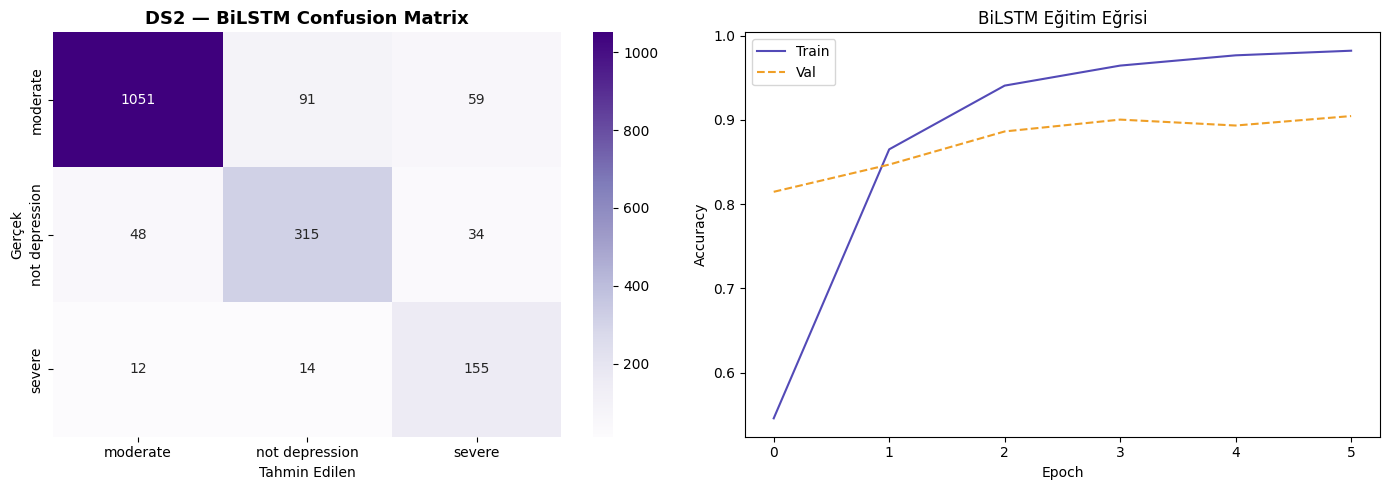

In [11]:
y2_pred_bilstm = np.argmax(model_bilstm2.predict(X2_test_pad), axis=1)

print("=" * 50)
print("DS2 — BiLSTM Classification Report")
print("=" * 50)
print(classification_report(y2_test, y2_pred_bilstm, target_names=label_names2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y2_test, y2_pred_bilstm), annot=True, fmt='d',
            cmap='Purples', xticklabels=label_names2, yticklabels=label_names2, ax=axes[0])
axes[0].set_title('DS2 — BiLSTM Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen')
axes[0].set_ylabel('Gerçek')

axes[1].plot(history2.history['accuracy'],     label='Train', color='#534AB7')
axes[1].plot(history2.history['val_accuracy'], label='Val',   color='#EF9F27', linestyle='--')
axes[1].set_title('BiLSTM Eğitim Eğrisi')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('ds2_bilstm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Cihaz: {device}")

class DepressionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = torch.tensor(labels.values, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

from huggingface_hub import login
login(token="your_token")

# MentalBERT tokenizer
tokenizer_bert2 = AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased")

train_enc2 = tokenizer_bert2(list(X2_train), max_length=128, padding='max_length',
                              truncation=True, return_tensors='pt')
test_enc2  = tokenizer_bert2(list(X2_test),  max_length=128, padding='max_length',
                              truncation=True, return_tensors='pt')

train_ds2 = DepressionDataset(train_enc2, y2_train)
test_ds2  = DepressionDataset(test_enc2,  y2_test)
train_loader2 = DataLoader(train_ds2, batch_size=16, shuffle=True)
test_loader2  = DataLoader(test_ds2,  batch_size=16)

weights2 = torch.tensor(list(class_weight_dict2.values()), dtype=torch.float).to(device)
loss_fn2  = torch.nn.CrossEntropyLoss(weight=weights2)

print(f"Train: {len(train_ds2)}, Test: {len(test_ds2)}")
print("Hazır!")

Cihaz: cuda


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Train: 7112, Test: 1779
Hazır!


In [13]:
model_bert2 = AutoModelForSequenceClassification.from_pretrained(
    "mental/mental-bert-base-uncased", num_labels=3
)
model_bert2.to(device)

optimizer2 = AdamW(model_bert2.parameters(), lr=2e-5, weight_decay=0.01)
scheduler2 = get_scheduler("linear", optimizer=optimizer2,
                            num_warmup_steps=50,
                            num_training_steps=len(train_loader2) * 4)

for epoch in range(4):
    model_bert2.train()
    total_loss = 0
    for batch in train_loader2:
        optimizer2.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model_bert2(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn2(outputs.logits, labels)
        loss.backward()
        optimizer2.step()
        scheduler2.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/4 — Loss: {total_loss/len(train_loader2):.4f}")

print("MentalBERT eğitimi tamamlandı!")

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if 

Epoch 1/4 — Loss: 0.6827
Epoch 2/4 — Loss: 0.2734
Epoch 3/4 — Loss: 0.1255
Epoch 4/4 — Loss: 0.0701
MentalBERT eğitimi tamamlandı!


DS2 — MentalBERT Classification Report
                precision    recall  f1-score   support

      moderate       0.92      0.94      0.93      1201
not depression       0.83      0.77      0.80       397
        severe       0.79      0.83      0.81       181

      accuracy                           0.89      1779
     macro avg       0.85      0.85      0.84      1779
  weighted avg       0.89      0.89      0.89      1779



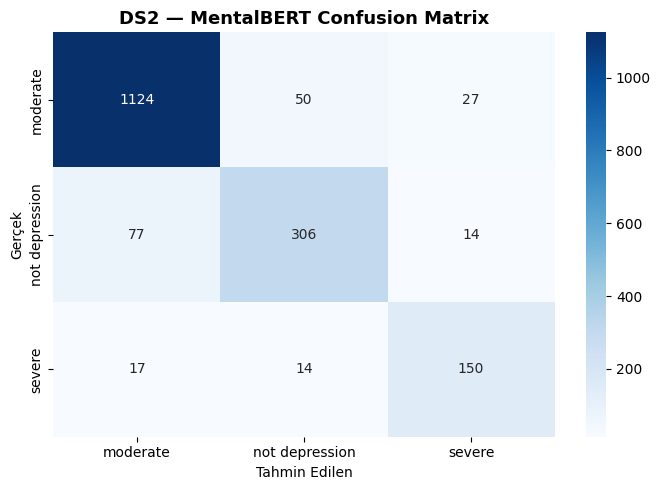

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

model_bert2.eval()
all_preds = []

with torch.no_grad():
    for batch in test_loader2:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = model_bert2(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

y2_pred_bert = np.array(all_preds)

print("=" * 50)
print("DS2 — MentalBERT Classification Report")
print("=" * 50)
print(classification_report(y2_test, y2_pred_bert, target_names=label_names2))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y2_test, y2_pred_bert), annot=True, fmt='d',
            cmap='Blues', xticklabels=label_names2, yticklabels=label_names2, ax=ax)
ax.set_title('DS2 — MentalBERT Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin Edilen')
ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig('ds2_mentalbert_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler

tokenizer_roberta2 = AutoTokenizer.from_pretrained("roberta-base")

train_enc_r2 = tokenizer_roberta2(list(X2_train), max_length=128, padding='max_length',
                                   truncation=True, return_tensors='pt')
test_enc_r2  = tokenizer_roberta2(list(X2_test),  max_length=128, padding='max_length',
                                   truncation=True, return_tensors='pt')

train_ds_r2 = DepressionDataset(train_enc_r2, y2_train)
test_ds_r2  = DepressionDataset(test_enc_r2,  y2_test)
train_loader_r2 = DataLoader(train_ds_r2, batch_size=16, shuffle=True)
test_loader_r2  = DataLoader(test_ds_r2,  batch_size=16)

model_roberta2 = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=3
)
model_roberta2.to(device)

optimizer_r2 = AdamW(model_roberta2.parameters(), lr=2e-5, weight_decay=0.01)
scheduler_r2 = get_scheduler("linear", optimizer=optimizer_r2,
                              num_warmup_steps=50,
                              num_training_steps=len(train_loader_r2) * 4)

for epoch in range(4):
    model_roberta2.train()
    total_loss = 0
    for batch in train_loader_r2:
        optimizer_r2.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model_roberta2(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn2(outputs.logits, labels)
        loss.backward()
        optimizer_r2.step()
        scheduler_r2.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/4 — Loss: {total_loss/len(train_loader_r2):.4f}")

print("RoBERTa eğitimi tamamlandı!")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 — Loss: 0.7975
Epoch 2/4 — Loss: 0.4254
Epoch 3/4 — Loss: 0.2498
Epoch 4/4 — Loss: 0.1552
RoBERTa eğitimi tamamlandı!


DS2 — RoBERTa Classification Report
                precision    recall  f1-score   support

      moderate       0.93      0.93      0.93      1201
not depression       0.82      0.78      0.80       397
        severe       0.76      0.84      0.80       181

      accuracy                           0.88      1779
     macro avg       0.83      0.85      0.84      1779
  weighted avg       0.88      0.88      0.88      1779



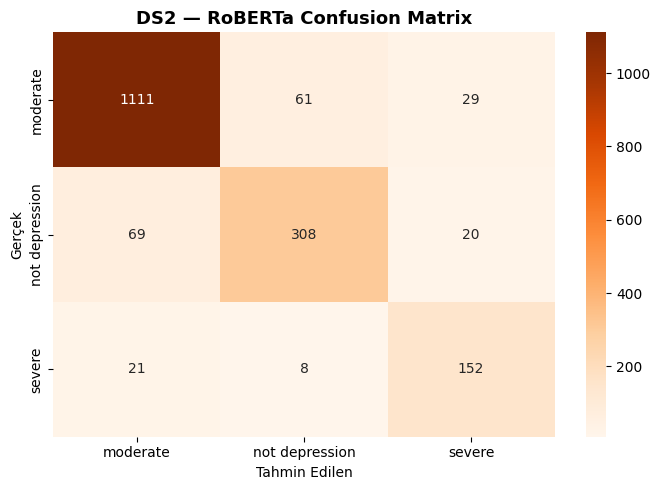

In [16]:
model_roberta2.eval()
all_preds_r2 = []

with torch.no_grad():
    for batch in test_loader_r2:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = model_roberta2(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds_r2.extend(preds.cpu().numpy())

y2_pred_roberta = np.array(all_preds_r2)

print("=" * 50)
print("DS2 — RoBERTa Classification Report")
print("=" * 50)
print(classification_report(y2_test, y2_pred_roberta, target_names=label_names2))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y2_test, y2_pred_roberta), annot=True, fmt='d',
            cmap='Oranges', xticklabels=label_names2, yticklabels=label_names2, ax=ax)
ax.set_title('DS2 — RoBERTa Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin Edilen')
ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig('ds2_roberta_cm.png', dpi=150, bbox_inches='tight')
plt.show()

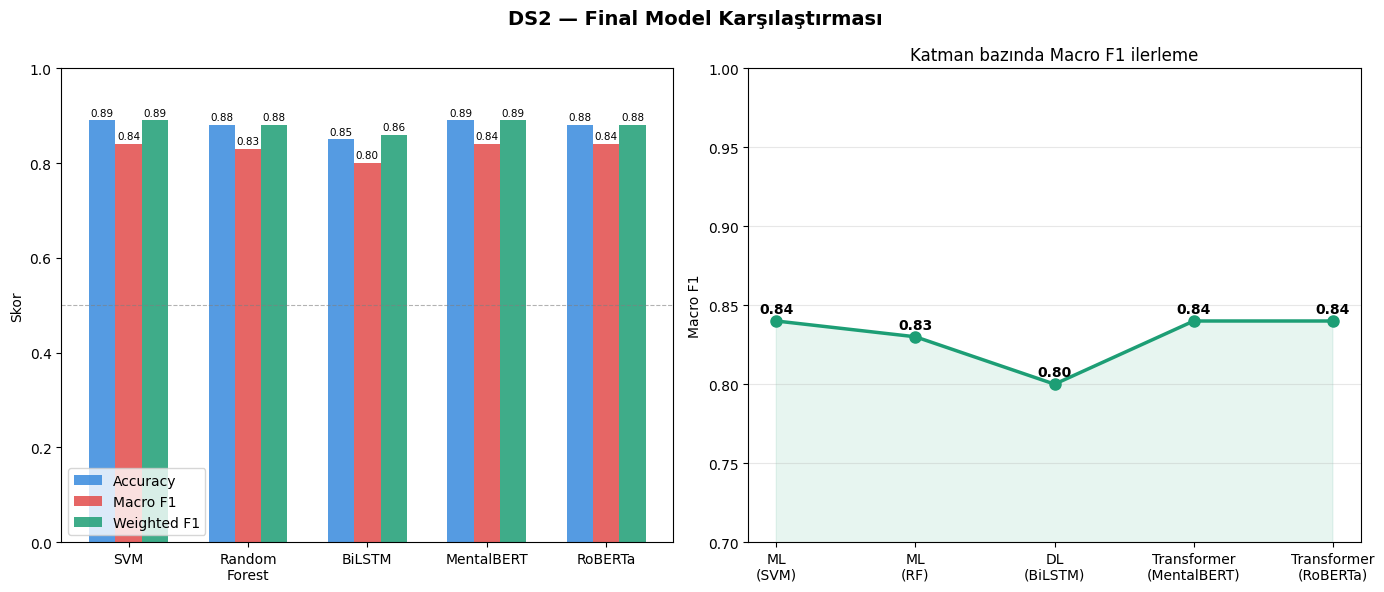

In [17]:
import numpy as np
import matplotlib.pyplot as plt

models      = ['SVM', 'Random\nForest', 'BiLSTM', 'MentalBERT', 'RoBERTa']
accuracy    = [0.89,  0.88,             0.85,      0.89,         0.88]
macro_f1    = [0.84,  0.83,             0.80,      0.84,         0.84]
weighted_f1 = [0.89,  0.88,             0.86,      0.89,         0.88]

x     = np.arange(len(models))
width = 0.22

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('DS2 — Final Model Karşılaştırması', fontsize=14, fontweight='bold')

b1 = axes[0].bar(x - width, accuracy,    width, label='Accuracy',    color='#378ADD', alpha=0.85)
b2 = axes[0].bar(x,         macro_f1,    width, label='Macro F1',    color='#E24B4A', alpha=0.85)
b3 = axes[0].bar(x + width, weighted_f1, width, label='Weighted F1', color='#1D9E75', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=10)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Skor')
axes[0].legend(fontsize=10)
axes[0].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for bars in [b1, b2, b3]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}', ha='center', fontsize=7.5)

katmanlar = ['ML\n(SVM)', 'ML\n(RF)', 'DL\n(BiLSTM)', 'Transformer\n(MentalBERT)', 'Transformer\n(RoBERTa)']
axes[1].plot(katmanlar, macro_f1, marker='o', linewidth=2.5,
             color='#1D9E75', markersize=8)
axes[1].fill_between(range(len(katmanlar)), macro_f1, alpha=0.1, color='#1D9E75')
for i, v in enumerate(macro_f1):
    axes[1].text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Katman bazında Macro F1 ilerleme')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ds2_final_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import json

ds2_results = {
    "SVM":        {"accuracy": 0.89, "macro_f1": 0.84, "weighted_f1": 0.89},
    "RF":         {"accuracy": 0.88, "macro_f1": 0.83, "weighted_f1": 0.88},
    "BiLSTM":     {"accuracy": 0.85, "macro_f1": 0.80, "weighted_f1": 0.86},
    "MentalBERT": {"accuracy": 0.89, "macro_f1": 0.84, "weighted_f1": 0.89},
    "RoBERTa":    {"accuracy": 0.88, "macro_f1": 0.84, "weighted_f1": 0.88},
}

with open('ds2_results.json', 'w') as f:
    json.dump(ds2_results, f, indent=2)

print("DS2 sonuçları kaydedildi!")
print(json.dumps(ds2_results, indent=2))

DS2 sonuçları kaydedildi!
{
  "SVM": {
    "accuracy": 0.89,
    "macro_f1": 0.84,
    "weighted_f1": 0.89
  },
  "RF": {
    "accuracy": 0.88,
    "macro_f1": 0.83,
    "weighted_f1": 0.88
  },
  "BiLSTM": {
    "accuracy": 0.85,
    "macro_f1": 0.8,
    "weighted_f1": 0.86
  },
  "MentalBERT": {
    "accuracy": 0.89,
    "macro_f1": 0.84,
    "weighted_f1": 0.89
  },
  "RoBERTa": {
    "accuracy": 0.88,
    "macro_f1": 0.84,
    "weighted_f1": 0.88
  }
}
